In [1]:
!pip install yfinance
!pip install bs4
!pip install nbformat
!pip install matplotlib

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     -------------------- ------------------- 1.6/3.0 MB 7.0 MB/s eta 0:00:01
     ---------------------------------------- 3.0/3.0 MB 9.9 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 46.2 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15618 sha256=e5293d70b4d8c3bc30b47c3913

  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [2]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup

In [3]:
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
# The make_graph function has been modified to use Matplotlib for static graphs. Earlier, it used Plotly to generate interactive dashboards, which caused issues when uploading the notebook in the MARK assignment submission.



import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

In [6]:
import yfinance as yf

tesla_ticker = yf.Ticker("TSLA")

print("Tesla Ticker object created successfully.")

Tesla Ticker object created successfully.


In [7]:
tesla_data = tesla_ticker.history(period="max")
print("Tesla historical stock data extracted successfully into 'tesla_data' DataFrame.")
# Display the first few rows of the DataFrame to confirm
display(tesla_data.head())

$TSLA: possibly delisted; no price data found  (1d 1926-12-30 -> 2025-12-05)


Tesla historical stock data extracted successfully into 'tesla_data' DataFrame.


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,


In [17]:
tesla_data.reset_index(inplace=True)
display(tesla_data.head())

,index,Date,Open,High,Low,Close,Adj Close,Volume


In [9]:
import requests

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
response = requests.get(url)
html_data = response.text

print("Webpage content downloaded and saved to 'html_data' variable.")

Webpage content downloaded and saved to 'html_data' variable.


In [10]:
from bs4 import BeautifulSoup

soup_revenue = BeautifulSoup(html_data, 'html.parser')

print("HTML data for revenue parsed successfully with BeautifulSoup.")

HTML data for revenue parsed successfully with BeautifulSoup.


In [11]:
import pandas as pd
tesla_revenue = pd.DataFrame(columns=['Date', 'Revenue'])
print("Empty 'tesla_revenue' DataFrame with 'Date' and 'Revenue' columns initialized.")
display(tesla_revenue.head())


Empty 'tesla_revenue' DataFrame with 'Date' and 'Revenue' columns initialized.


,Date,Revenue


In [12]:
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"",regex=True)

In [13]:
tesla_revenue.dropna(inplace=True)

tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

In [14]:
display(tesla_revenue.tail())

,Date,Revenue


In [15]:
import yfinance as yf

gme_ticker = yf.Ticker("GME")

print("GameStop Ticker object created successfully.")

GameStop Ticker object created successfully.


In [16]:
gme_data = gme_ticker.history(period="max")
print("GameStop historical stock data extracted successfully into 'gme_data' DataFrame.")
display(gme_data.head())

GameStop historical stock data extracted successfully into 'gme_data' DataFrame.


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [18]:
gme_data.reset_index(inplace=True)
display(gme_data.head())

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [19]:
url_2 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
response_2 = requests.get(url_2)
html_data_2 = response_2.text

print("Webpage content downloaded and saved to 'html_data_2' variable.")

Webpage content downloaded and saved to 'html_data_2' variable.


In [20]:
from bs4 import BeautifulSoup

soup_gme_revenue = BeautifulSoup(html_data_2, 'html.parser')

print("HTML data for revenue parsed successfully with BeautifulSoup.")

HTML data for revenue parsed successfully with BeautifulSoup.


In [21]:
import pandas as pd
gme_revenue = pd.DataFrame(columns=['Date', 'Revenue'])
print("Empty 'gme_revenue' DataFrame with 'Date' and 'Revenue' columns initialized.")
display(gme_revenue.head())

Empty 'gme_revenue' DataFrame with 'Date' and 'Revenue' columns initialized.


,Date,Revenue


In [22]:
for table in soup_gme_revenue.find_all('table'):
    if table.find('th') and 'GameStop Quarterly Revenue' in table.find('th').getText():
        for row in table.find('tbody').find_all('tr'):
            col = row.find_all('td')
            date = col[0].text
            revenue = col[1].text.replace('$', '').replace(',', '')
            gme_revenue = pd.concat([gme_revenue, pd.DataFrame([{'Date': date, 'Revenue': revenue}])], ignore_index=True)

print("Extracted 'Date' and 'Revenue' data from HTML and populated 'gme_revenue' DataFrame.")
display(gme_revenue.head())

Extracted 'Date' and 'Revenue' data from HTML and populated 'gme_revenue' DataFrame.


,Date,Revenue
0,2020-04-30,1021
1,2020-01-31,2194
2,2019-10-31,1439
3,2019-07-31,1286
4,2019-04-30,1548


In [23]:
gme_revenue['Revenue'] = pd.to_numeric(gme_revenue['Revenue'], errors='coerce')
gme_revenue.dropna(inplace=True)
gme_revenue['Date'] = pd.to_datetime(gme_revenue['Date'])

print("Converted 'Date' column to datetime and 'Revenue' to numeric type, handling missing values.")
display(gme_revenue.head())

Converted 'Date' column to datetime and 'Revenue' to numeric type, handling missing values.


,Date,Revenue
0,2020-04-30,1021
1,2020-01-31,2194
2,2019-10-31,1439
3,2019-07-31,1286
4,2019-04-30,1548


In [24]:
display(gme_revenue.head())

,Date,Revenue
0,2020-04-30,1021
1,2020-01-31,2194
2,2019-10-31,1439
3,2019-07-31,1286
4,2019-04-30,1548


In [25]:
display(gme_revenue.tail())

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


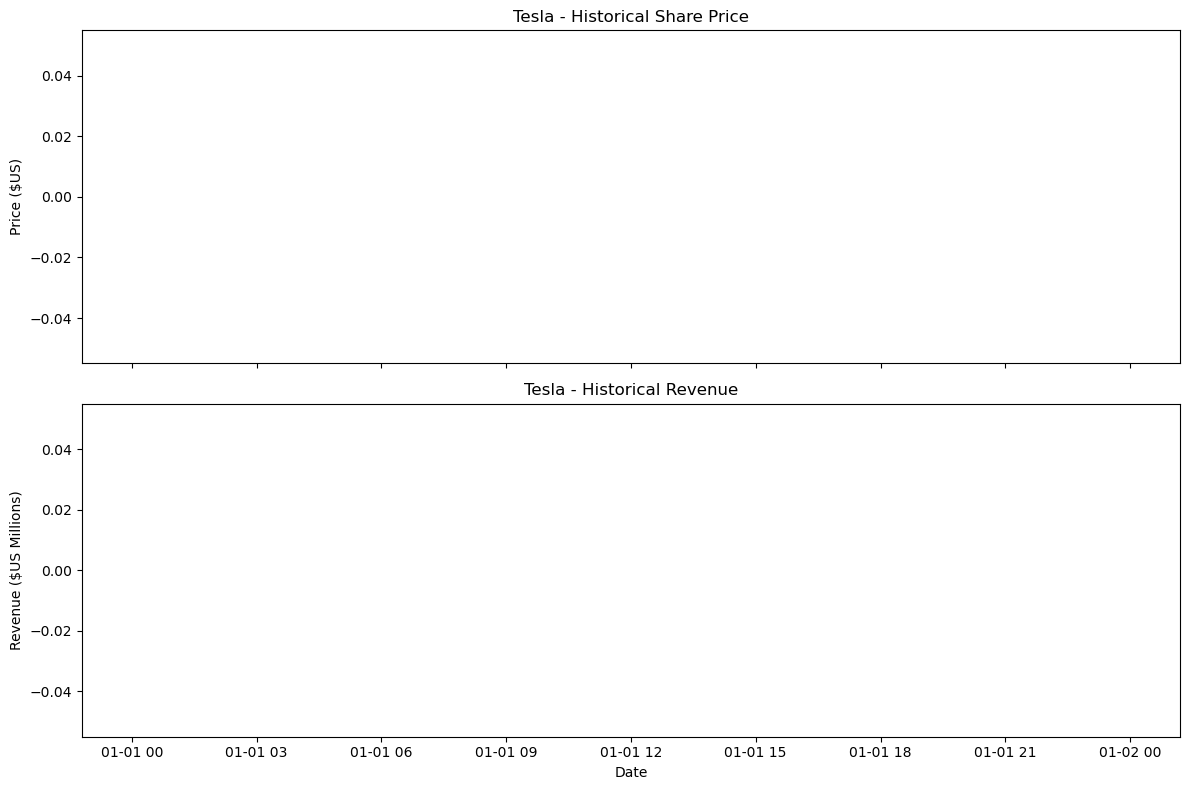

In [26]:
make_graph(tesla_data, tesla_revenue, 'Tesla')

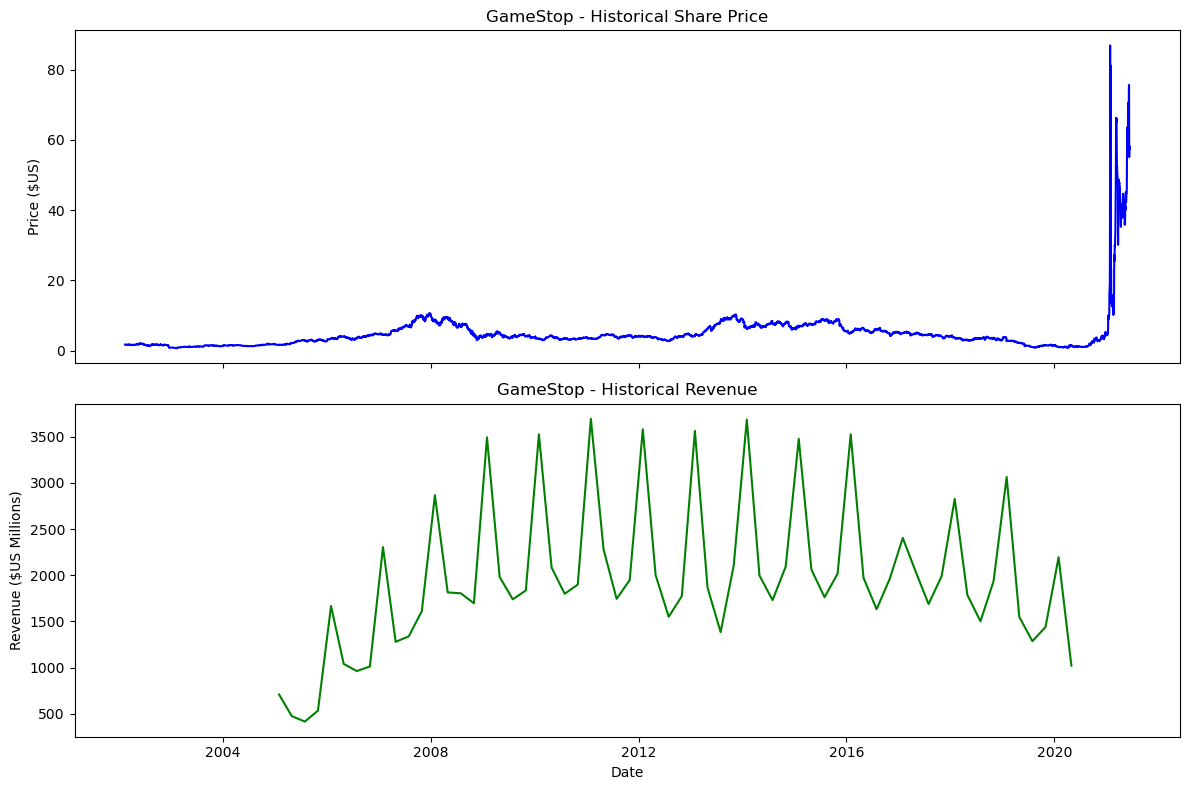

In [27]:
make_graph(gme_data, gme_revenue, 'GameStop')